# Create Identity Photo for the Front Desk Agent

In [1]:
# Import required libraries
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# sklearn libraries 
from sklearn.base import (BaseEstimator, 
                            TransformerMixin)
from IPython.display import (Markdown, 
                            display)


# Import Transformer Packages
from transformers import pipeline
from transformers import (AutoModelForImageClassification, 
                            AutoImageProcessor)

from PIL import Image


# load env variables
from dotenv import load_dotenv
load_dotenv()

/Users/kavisanthoshkumar/Documents/GenerativeAIusingAWS/healthcare_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

# 1. Build the Vision Model for Gender Classification (Image Classification Task)

In [2]:
# Loading it as pipeline
pipe = pipeline(
    "image-classification", 
    model = 'rizvandwiki/gender-classification'
)

# Loading processor and model seperately using huggingface library
processor = AutoImageProcessor.from_pretrained("rizvandwiki/gender-classification")
model = AutoModelForImageClassification.from_pretrained("rizvandwiki/gender-classification")

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 22758.02it/s]


## 1.1 AI Generated Images

Think that your team is sitting in the hospital front desk and using AI Agents for Identity Verification 

     1. We are generated these AI images because we don't have access to the real world datasets

     2. But in real time we will be capturing the images throught the kisosik and we have to predict basis of the image whether the person is male or female and the age group



In [15]:
# We are just getting the random image from the request
image_url = "https://thispersondoesnotexist.com"
image = Image.open(requests.get(image_url, stream = True).raw)

In machine learning, particularly in classification tasks, logits are the raw, unnormalized outputs produced by a model's final layer before any activation function is applied. These outputs represent the model's confidence scores for each class and are essential for subsequent probability calculations

## 1.2 Generate Gender Prediction

In [ ]:
def GenderPredictionFromPreTrainedModel(image, image_processor, model) -> int:
    """
        Function : Function used to generate gender prediction using pretrained huggingface model

        Arguments :
            image: Input Image
            image_processor: PreTrained Processor 
            model : PreTrained Model
    """
    # Prepare the image for the model
    inputs = image_processor(images = image, return_tensors = 'pt')

    # Generate predictions
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = logits.argmax(-1).item()

    # Map the prediction to the class
    classes = model.config.id2label
    gender_label = classes[predicted_class]

    print(f"Gender Prediction using Pre-Trained Model : {gender_label}")

    return gender_label 

gender_label = GenderPredictionFromPreTrainedModel(
    image = image, 
    image_processor = processor, 
    model = model
)

Gender Prediction using Pre-Trained Model : male


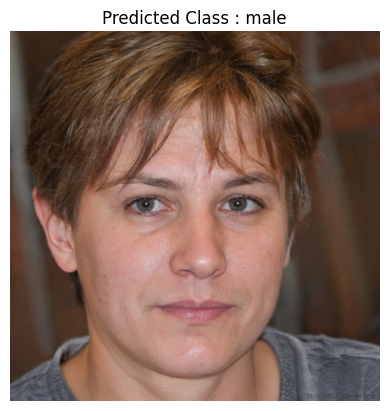

In [18]:
# Display the image and prediction
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted Class : {gender_label}")
plt.show()

# 2. Build the Vision Model for Age Classification (Image Classification Task)

In [21]:
# load age classfication model
age_model_name = 'nateraw/vit-age-classifier'
age_model = AutoModelForImageClassification.from_pretrained(age_model_name)
age_model_processor = AutoImageProcessor.from_pretrained(age_model_name)


def AgePredictionForPretrainedModel(image, age_model, age_model_processor):
    """
        Function : We are gonna pretrained Model for predicting the age 

        Arguments :
            image : Input Image 
            age_model_processor : Pass the pretrained processor from the huggingface 
            age_model : Pass the pretrained model from the huggingface
    """
    # Prepare the image for the model consumption
    inputs = age_model_processor(image, return_tensors = 'pt')

    # Generate Predictions
    outputs = age_model(**inputs)
    logits = outputs.logits
    predicted_class = logits.argmax(-1).item()


    # Map the prediction to the class label 
    classes = age_model.config.id2label
    age_prediction_class =classes[predicted_class]
    print(f"Age Prediction to the Class: {age_prediction_class}")

    return age_prediction_class


AgePredictionForPretrainedModel(
    image = image,
    age_model = age_model, 
    age_model_processor = age_model_processor
)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 28249.23it/s]


Age Prediction to the Class: 20-29


'20-29'